# 03 Exploratory Data Analysis

This notebook explores the cleaned dataset to identify trends, distributions, and potential relationships, particularly focusing on the central problem statement: Are high severity classifications conflated with congestion or location bias?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data/processed/cleaned_dataset.csv'
PLOT_DIR = PROJECT_ROOT / 'reports/eda_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Loaded dataset with 95607 rows and 46 columns.


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Street,City,County,State,Zipcode,Timezone,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Year,Month,Day_of_Week,Day_Name,Hour,Is_Weekend,Time_of_Day,Season,Duration_min,Road_Feature_Count,Is_Rush_Hour
0,4,2017-02-25 01:21:34,2017-02-25 07:21:34,29.949330,-95.291820,1.718,US-59 S,Humble,Harris,TX,77396,US/Central,55.0,53.0,29.98,10.0,North,8.1,Clear,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2017.0,2.0,5.0,Saturday,1.0,True,Night,Winter,360.000000,0,False
1,4,2022-10-13 23:14:46,2022-10-14 01:15:36,35.037490,-89.795978,0.371,Bill Morris Pkwy,Memphis,Shelby,TN,38125,US/Central,52.0,67.0,29.51,10.0,CALM,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,True,Night,Night,Night,Night,2022.0,10.0,3.0,Thursday,23.0,False,Night,Fall,120.833333,1,False
2,3,2018-12-03 05:54:08,2018-12-03 06:23:59,37.824001,-122.316925,0.000,I-80 W,Oakland,Alameda,CA,94607,US/Pacific,46.9,74.0,30.20,10.0,East,6.9,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,Night,Night,Night,Day,2018.0,12.0,0.0,Monday,5.0,False,Morning,Winter,29.850000,1,False
3,4,2019-06-24 16:18:39,2019-06-24 16:47:09,44.477478,-88.470745,0.407,W5590 State Highway 54,Black Creek,Outagamie,WI,54106,US/Central,63.0,94.0,28.59,3.0,WSW,14.0,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2019.0,6.0,0.0,Monday,16.0,False,Afternoon,Summer,28.500000,0,True
4,2,2021-06-13 17:43:00,2021-06-13 18:46:00,33.956033,-118.109349,1.411,I-5 S,Downey,Los Angeles,CA,90240,US/Pacific,76.0,46.0,29.67,10.0,CALM,0.0,Fair,False,False,False,False,True,False,False,False,False,False,False,False,Day,Day,Day,Day,2021.0,6.0,6.0,Sunday,17.0,True,Evening,Summer,63.000000,1,True


## 1. Severity Distribution
Let's see the distribution of severity in our sampled dataset.

/var/folders/dc/cl35b8s17l712b9krwhx9ztw0000gn/T/ipykernel_13124/1648546851.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Severity', palette='viridis')


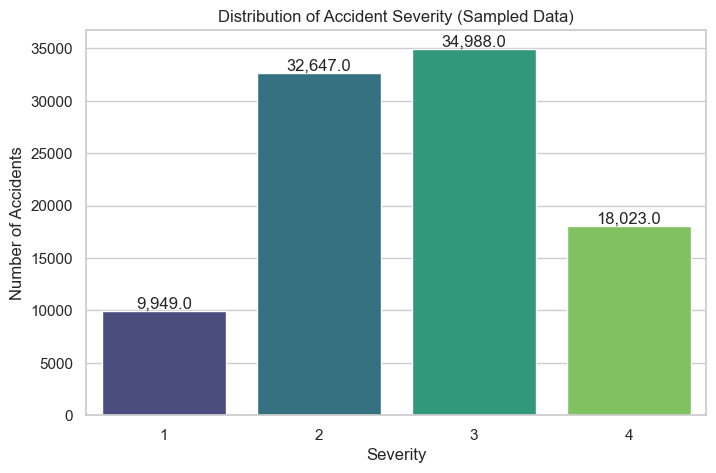

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Severity', palette='viridis')
plt.title('Distribution of Accident Severity (Sampled Data)')
plt.ylabel('Number of Accidents')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.savefig(PLOT_DIR / 'severity_distribution.png', bbox_inches='tight')
plt.show()

## 2. Temporal Analysis

/var/folders/dc/cl35b8s17l712b9krwhx9ztw0000gn/T/ipykernel_13124/771339441.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Year', ax=axes[0, 0], palette='Blues_d')
/var/folders/dc/cl35b8s17l712b9krwhx9ztw0000gn/T/ipykernel_13124/771339441.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Month', ax=axes[0, 1], palette='Oranges_d')
/var/folders/dc/cl35b8s17l712b9krwhx9ztw0000gn/T/ipykernel_13124/771339441.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Day_Name', order=['Monday', 'Tuesday',

/var/folders/dc/cl35b8s17l712b9krwhx9ztw0000gn/T/ipykernel_13124/771339441.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Hour', ax=axes[1, 1], palette='Reds_d')


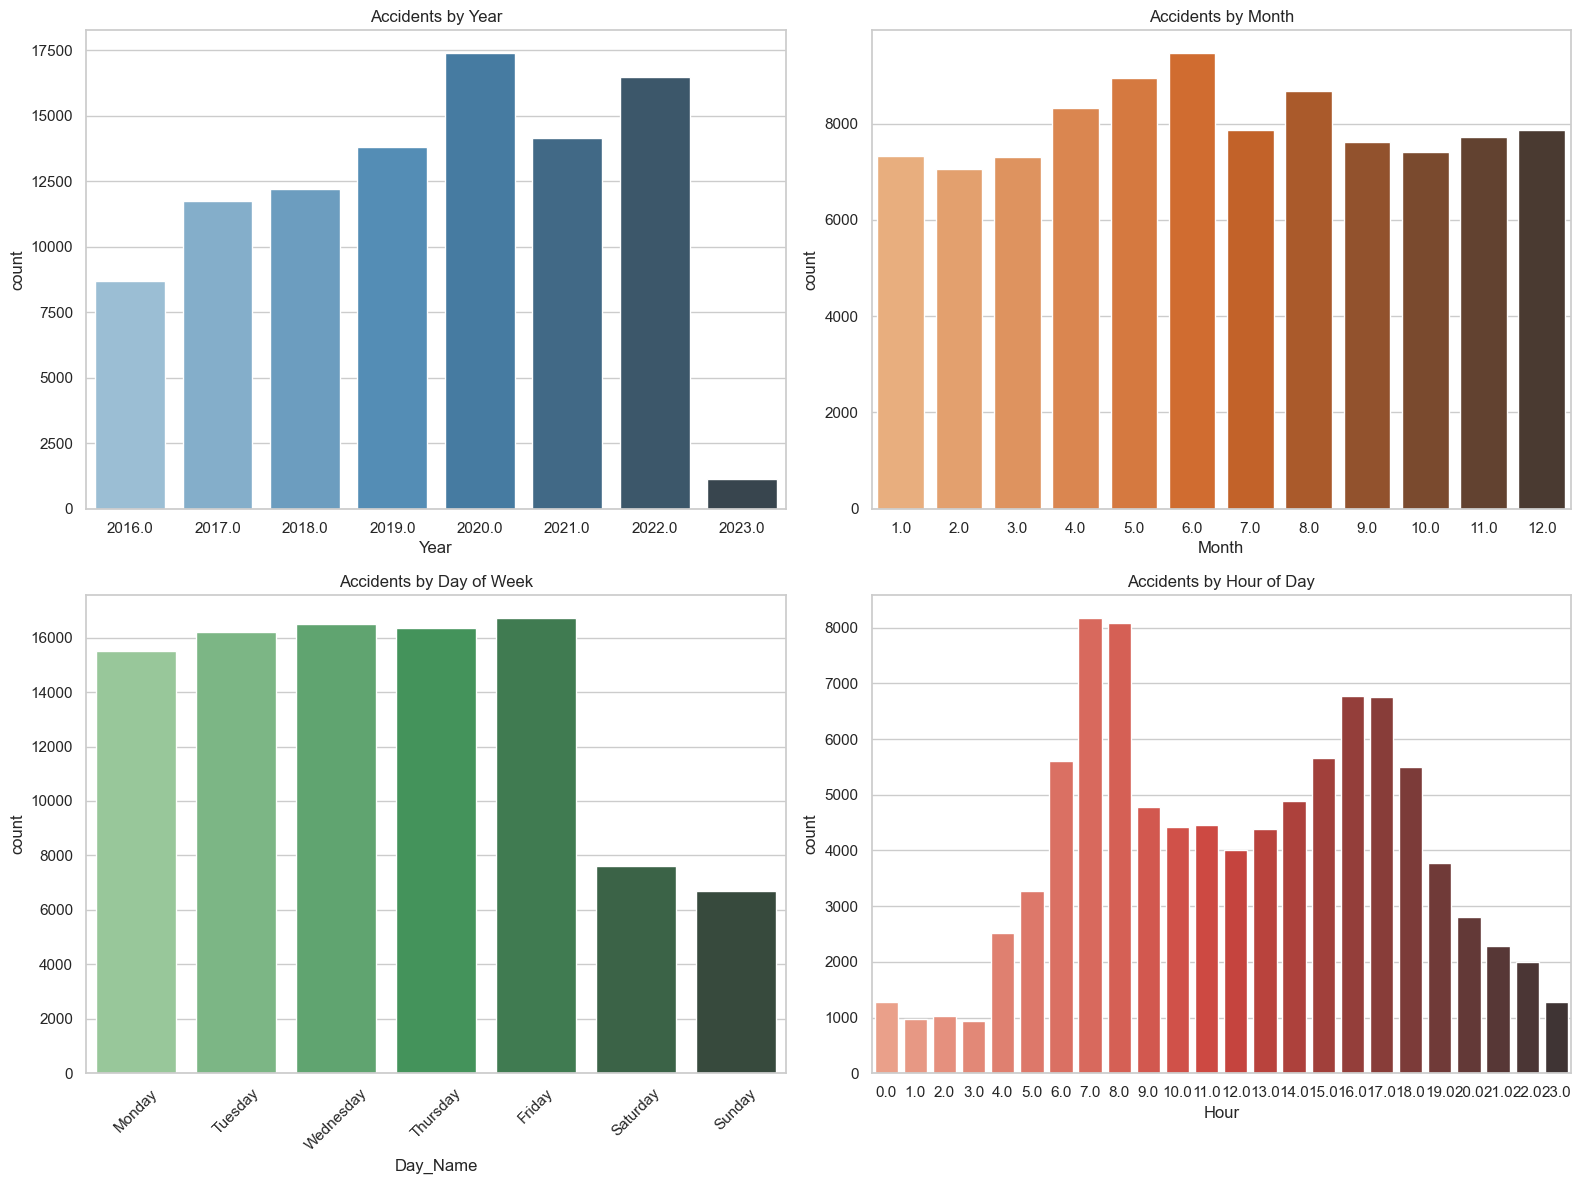

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accidents by Year
sns.countplot(data=df, x='Year', ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Accidents by Year')

# Accidents by Month
sns.countplot(data=df, x='Month', ax=axes[0, 1], palette='Oranges_d')
axes[0, 1].set_title('Accidents by Month')

# Accidents by Day of Week
sns.countplot(data=df, x='Day_Name', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ax=axes[1, 0], palette='Greens_d')
axes[1, 0].set_title('Accidents by Day of Week')
axes[1, 0].tick_params(axis='x', rotation=45)

# Accidents by Hour
sns.countplot(data=df, x='Hour', ax=axes[1, 1], palette='Reds_d')
axes[1, 1].set_title('Accidents by Hour of Day')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'temporal_analysis.png', bbox_inches='tight')
plt.show()

### Heatmap: Day of Week vs Hour

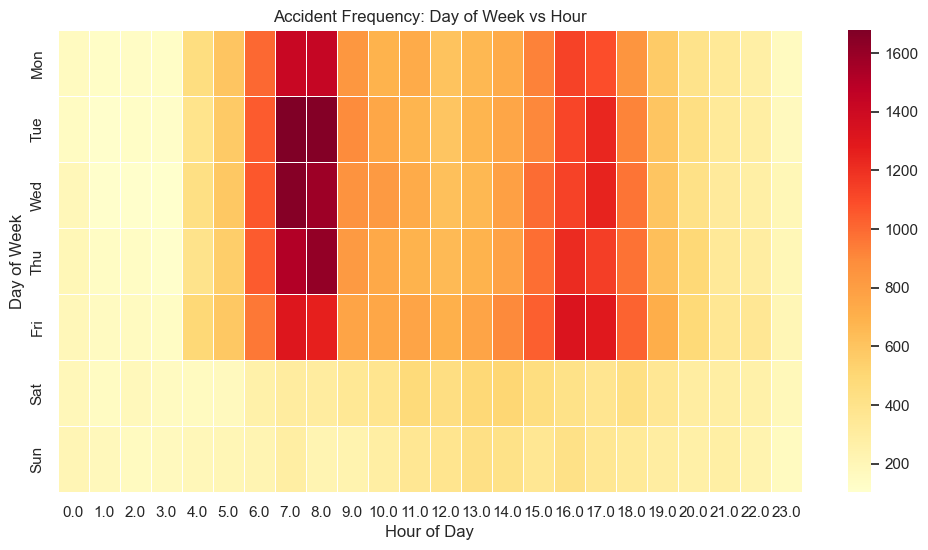

In [5]:
pivot = df.pivot_table(index='Day_of_Week', columns='Hour', values='Severity', aggfunc='count')
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=.5)
plt.title('Accident Frequency: Day of Week vs Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.savefig(PLOT_DIR / 'heatmap_day_hour.png', bbox_inches='tight')
plt.show()

## 3. Geographic Analysis

/var/folders/dc/cl35b8s17l712b9krwhx9ztw0000gn/T/ipykernel_13124/3172811313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.index, y=top_states.values, palette='magma')


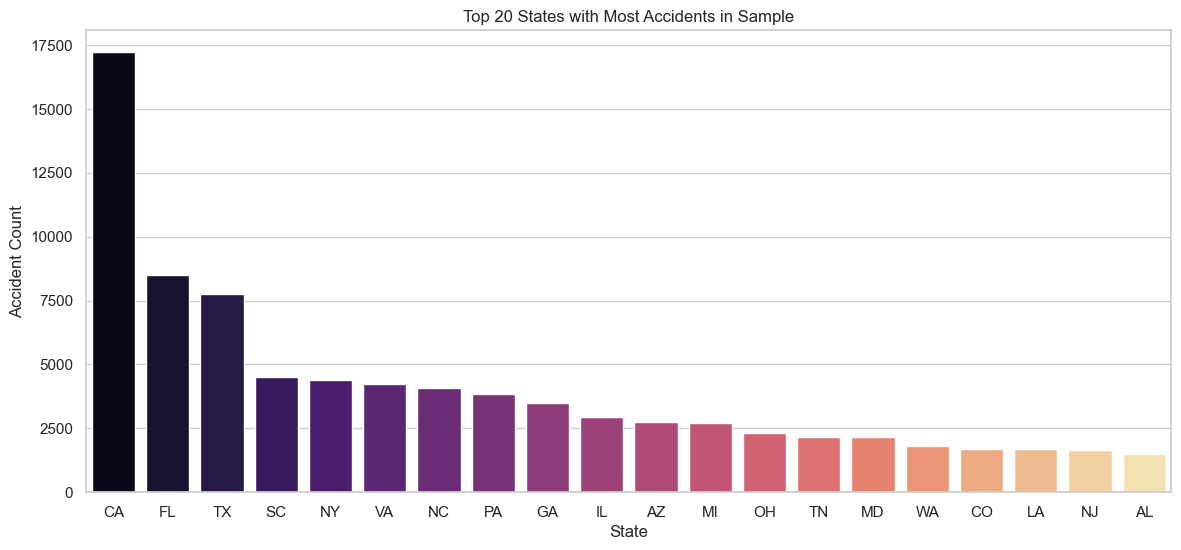

In [6]:
plt.figure(figsize=(14, 6))
top_states = df['State'].value_counts().nlargest(20)
sns.barplot(x=top_states.index, y=top_states.values, palette='magma')
plt.title('Top 20 States with Most Accidents in Sample')
plt.ylabel('Accident Count')
plt.xlabel('State')
plt.savefig(PLOT_DIR / 'top_states.png', bbox_inches='tight')
plt.show()

## 4. Weather Impact

/var/folders/dc/cl35b8s17l712b9krwhx9ztw0000gn/T/ipykernel_13124/2910912010.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_weather.index, x=top_weather.values, palette='coolwarm')


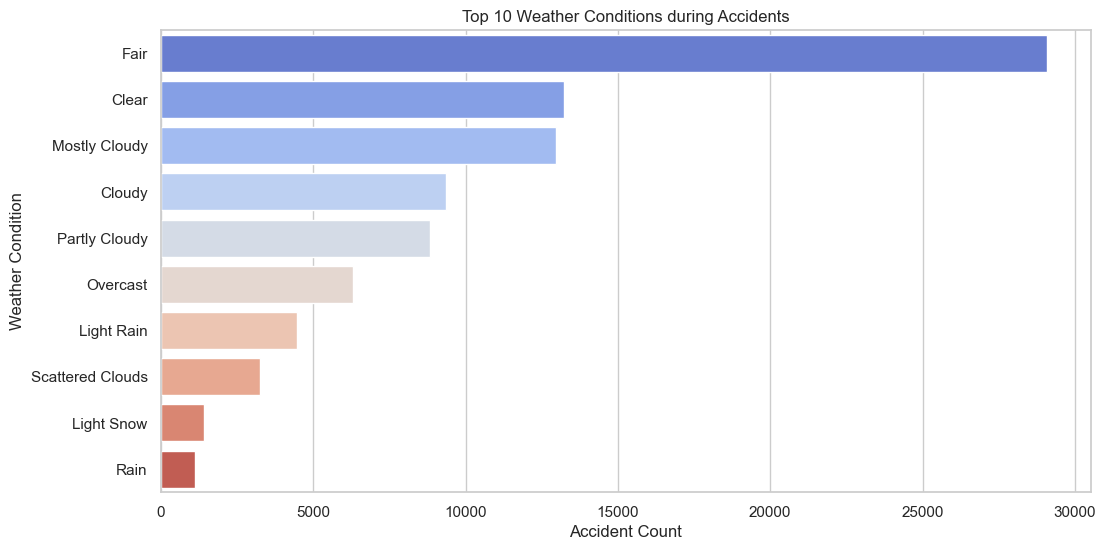

In [7]:
plt.figure(figsize=(12, 6))
top_weather = df['Weather_Condition'].value_counts().nlargest(10)
sns.barplot(y=top_weather.index, x=top_weather.values, palette='coolwarm')
plt.title('Top 10 Weather Conditions during Accidents')
plt.xlabel('Accident Count')
plt.ylabel('Weather Condition')
plt.savefig(PLOT_DIR / 'top_weather.png', bbox_inches='tight')
plt.show()

## 5. Congestion vs Severity Investigation
Problem Statement Focus: Are "high risk/high severity" assignments just a product of rush hour congestion?

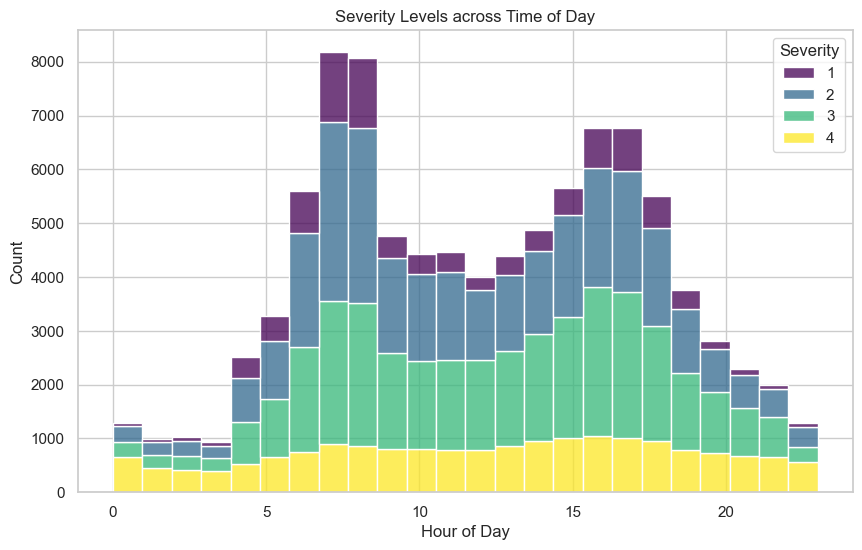

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Hour', hue='Severity', multiple='stack', bins=24, palette='viridis')
plt.title('Severity Levels across Time of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.savefig(PLOT_DIR / 'severity_by_hour.png', bbox_inches='tight')
plt.show()

In [9]:
# Compare Severity proportions in Rush Hour vs Non-Rush Hour
rush_hour_crosstab = pd.crosstab(df['Is_Rush_Hour'], df['Severity'], normalize='index') * 100
print("Severity Proportions (Row %): Rush Hour vs Non-Rush Hour")
display(rush_hour_crosstab.round(2))

Severity Proportions (Row %): Rush Hour vs Non-Rush Hour


Severity,1,2,3,4
Is_Rush_Hour,,,,
False,8.63,32.46,36.37,22.53
True,12.50,36.14,36.86,14.50


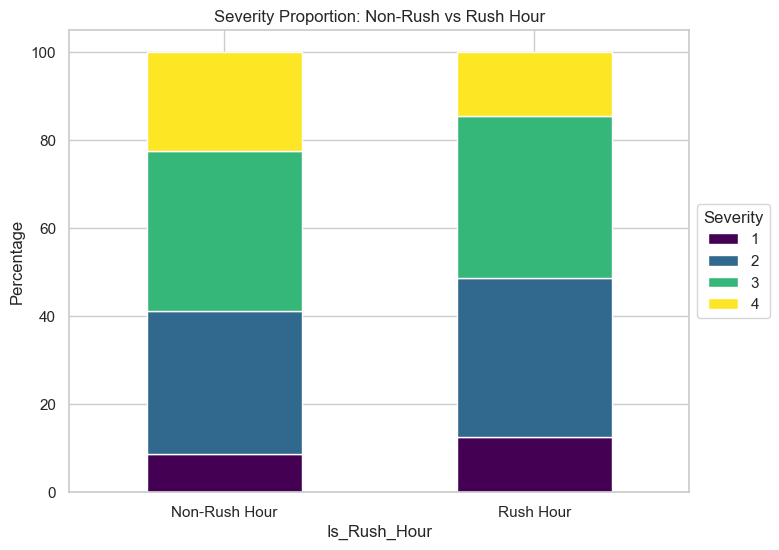

In [10]:
rush_hour_crosstab.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='viridis')
plt.title('Severity Proportion: Non-Rush vs Rush Hour')
plt.ylabel('Percentage')
plt.xticks([0, 1], ['Non-Rush Hour', 'Rush Hour'], rotation=0)
plt.legend(title='Severity', loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.savefig(PLOT_DIR / 'severity_rush_hour.png', bbox_inches='tight')
plt.show()

**Insight**: If severity is just "impact on traffic", we might expect higher severity *during* rush hour due to compounding delays. However, the data will show if severity 4 (longest delay) happens mostly outside rush hour (due to severe crashes) or during rush hour (due to volume).

## 6. Correlation Analysis

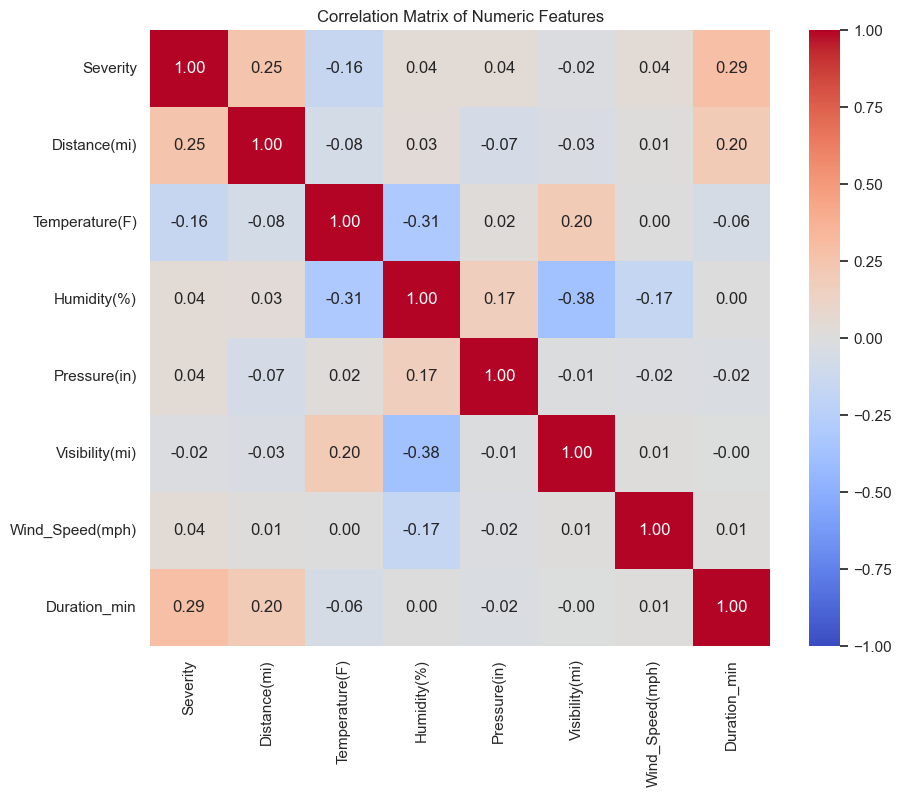

In [11]:
numeric_cols = ['Severity', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Duration_min']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.savefig(PLOT_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()